<a href="https://colab.research.google.com/github/rsouparnika/ML-2/blob/main/Program_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Dataset shape: (150, 5)

Training samples: 120
Testing samples: 30

========== BAGGING ==========
Accuracy: 0.9666666666666667

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30


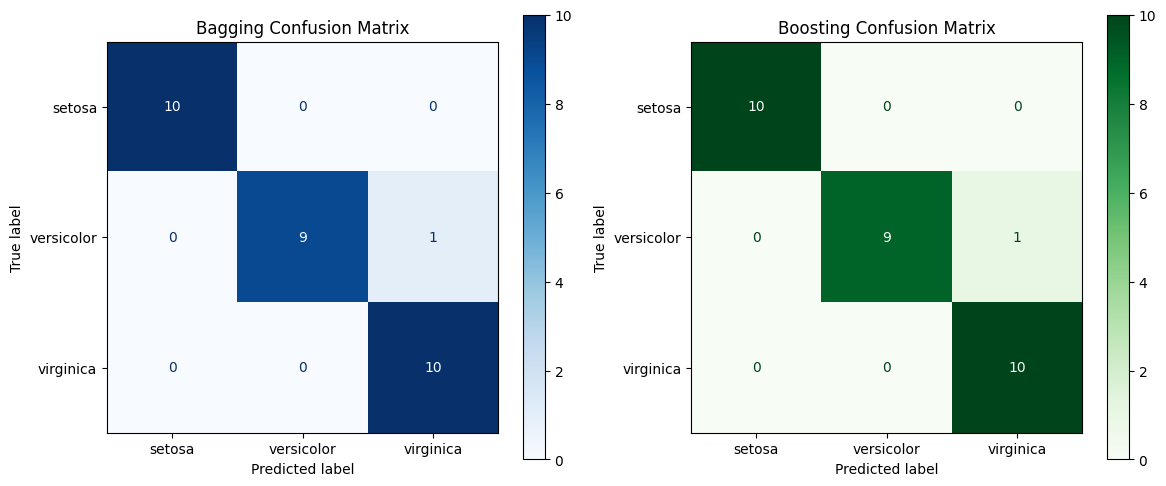

In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ----------------------------------------------------
# 1. Load the supervised dataset
# ----------------------------------------------------

iris = load_iris()

X = iris.data
y = iris.target

# Convert dataset into a DataFrame
df = pd.DataFrame(X, columns=iris.feature_names)
df["target"] = y

print("First 5 rows of the dataset:")
print(df.head())

print("\nDataset shape:", df.shape)

# ----------------------------------------------------
# 2. Split dataset into training and testing data
# ----------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

# ----------------------------------------------------
# 3. BAGGING
# ----------------------------------------------------

bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42
)

# Train the model
bagging_model.fit(X_train, y_train)

# Make predictions
y_pred_bagging = bagging_model.predict(X_test)

# Calculate accuracy
bagging_accuracy = accuracy_score(y_test, y_pred_bagging)

print("\n========== BAGGING ==========")
print("Accuracy:", bagging_accuracy)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_bagging,
    target_names=iris.target_names
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_bagging))

# ----------------------------------------------------
# 4. BOOSTING
# ----------------------------------------------------

boosting_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

# Train the model
boosting_model.fit(X_train, y_train)

# Make predictions
y_pred_boosting = boosting_model.predict(X_test)

# Calculate accuracy
boosting_accuracy = accuracy_score(y_test, y_pred_boosting)

print("\n========== BOOSTING ==========")
print("Accuracy:", boosting_accuracy)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_boosting,
    target_names=iris.target_names
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_boosting))

# ----------------------------------------------------
# 5. Compare Bagging and Boosting
# ----------------------------------------------------

print("\n========== MODEL COMPARISON ==========")

print("Bagging Accuracy :", bagging_accuracy)
print("Boosting Accuracy:", boosting_accuracy)

# ----------------------------------------------------
# 6. Plot confusion matrices
# ----------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_bagging,
    display_labels=iris.target_names,
    ax=axes[0],
    cmap="Blues"
)

axes[0].set_title("Bagging Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_boosting,
    display_labels=iris.target_names,
    ax=axes[1],
    cmap="Greens"
)

axes[1].set_title("Boosting Confusion Matrix")

plt.tight_layout()
plt.show()
